# Creative Writing - 3. MOJO Routing Analysis

## Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 20

POSITIVE_CATEGORIES = [
    "Adherence to Instructions", "Believable Character Actions", "Nuanced Characters",
    "Consistent Voice / Tone of Writing", "Imagery and Descriptive Quality", "Elegant Prose",
    "Emotionally Engaging", "Emotionally Complex", "Coherent",
    "Well-earned Lightness or Darkness", "Sentences Flow Naturally",
    "Overall Reader Engagement", "Overall Impression",
]
NEGATIVE_CATEGORIES = [
    "Meandering", "Weak Dialogue", "Tell-Don't-Show", "Unsurprising or Uncreative",
    "Amateurish", "Purple Prose", "Overwrought",
    "Incongruent Ending Positivity", "Unearned Transformations",
]
ALL_CATEGORIES = POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES
POS_COLS = [f"{c}_score" for c in POSITIVE_CATEGORIES]
NEG_COLS = [f"{c}_score" for c in NEGATIVE_CATEGORIES]
ALL_COLS = POS_COLS + NEG_COLS

def pretty_model(stem: str) -> str:
    return stem.replace("_result", "")

## Cost (for CLAUDE_BLENDED and cost_df)

In [2]:
def parse_log(path: Path) -> dict:
    tot_tok = lat = prompt = completion = n_ok = n_total = 0
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            n_total += 1
            if e.get("status") == "ok":
                tot_tok    += e["total_tokens"]
                lat        += e["latency_ms"] / 1000
                prompt     += e["prompt_tokens"]
                completion += e["completion_tokens"]
                n_ok += 1
    return dict(n_ok=n_ok, n_total=n_total,
                total_tokens=tot_tok, latency_s=lat,
                prompt_tokens=prompt, completion_tokens=completion)

# Claude baseline
claude_raw = parse_log(LOGS_DIR / "llm_calls_claude-sonnet-4-6.jsonl")
claude_cost_total = (
    claude_raw["prompt_tokens"]     * CLAUDE_PRICE_INPUT  / 1_000_000
    + claude_raw["completion_tokens"] * CLAUDE_PRICE_OUTPUT / 1_000_000
)
CLAUDE_BLENDED = claude_cost_total / claude_raw["total_tokens"] * 1_000_000

print(f"Claude Sonnet 4.6  |  {claude_raw['n_ok']:,} requests  "
      f"|  blended ${CLAUDE_BLENDED:.2f}/1M tokens")

# Open-source models
cost_rows = []
for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    tput      = raw["total_tokens"] / raw["latency_s"]
    cost_low  = (1_000_000 / (tput * 3600)) * GPU_RATE_LOW
    cost_high = (1_000_000 / (tput * 3600)) * GPU_RATE_HIGH
    name = log_file.stem.replace("llm_calls_", "")
    cost_rows.append(dict(
        model=pretty_model(name),
        n_ok=raw["n_ok"],
        throughput=tput,
        cost_low=cost_low,
        cost_high=cost_high,
        cost_mid=(cost_low + cost_high) / 2,
        reduction_low=CLAUDE_BLENDED / cost_low,
        reduction_high=CLAUDE_BLENDED / cost_high,
    ))

cost_df = pd.DataFrame(cost_rows).sort_values("cost_low").reset_index(drop=True)

disp = cost_df[["model","n_ok","throughput","cost_low","cost_high","reduction_low","reduction_high"]].copy()
disp.columns = ["Model","N (ok)","Throughput (tok/s)","Cost/1M low","Cost/1M high","Reduction low","Reduction high"]
disp["Throughput (tok/s)"] = disp["Throughput (tok/s)"].map("{:.0f}".format)
disp["Cost/1M low"]  = disp["Cost/1M low"].map("${:.3f}".format)
disp["Cost/1M high"] = disp["Cost/1M high"].map("${:.3f}".format)
disp["Reduction low"]  = disp["Reduction low"].map("{:.1f}x".format)
disp["Reduction high"] = disp["Reduction high"].map("{:.1f}x".format)
display(disp)

Claude Sonnet 4.6  |  767 requests  |  blended $4.28/1M tokens


,Model,N (ok),Throughput (tok/s),Cost/1M low,Cost/1M high,Reduction low,Reduction high
0,Llama-3.2-3B-Instruct,811,2086,$0.266,$0.466,16.1x,9.2x
1,NVIDIA-Nemotron-3-Nano-4B-BF16,767,1706,$0.326,$0.570,13.1x,7.5x
2,gemma-4-E2B-it,767,1525,$0.364,$0.638,11.7x,6.7x
3,Qwen3.5-4B,767,1262,$0.440,$0.770,9.7x,5.6x
4,Qwen3-4B-Instruct-2507,767,1250,$0.444,$0.778,9.6x,5.5x
5,gemma-4-E4B-it,767,1012,$0.549,$0.960,7.8x,4.5x


## MOJO routing analysis

For each MAE threshold Tol, MOJO routes each rubric to the cheapest open-source model whose bootstrap UCB-MAE ≤ Tol, falling back to Claude otherwise.

In [3]:
def _load_pairs():
    """Load result CSVs and return (pairs, errors, evaluator_names) for bootstrap."""
    id_keys  = ["index", "model"]
    raw      = {p.stem: pd.read_csv(p) for p in sorted(RESULTS_DIR.glob("*_result.csv"))}
    baseline = pd.read_csv(RESULTS_DIR / BASELINE_FILE)
    raw.pop(Path(BASELINE_FILE).stem, None)

    evaluators      = {pretty_model(k): v for k, v in raw.items()}
    evaluator_names = sorted(evaluators.keys())

    pair_frames, err_frames = [], []
    for name, df in evaluators.items():
        m = df.merge(baseline, on=id_keys, suffixes=("_ev", "_ref"), validate="one_to_one")
        for cat in ALL_CATEGORIES:
            col = f"{cat}_score"
            ref = m[f"{col}_ref"].to_numpy()
            sc  = m[f"{col}_ev"].to_numpy()
            pair_frames.append(pd.DataFrame({
                "evaluator": name,
                "category":  cat,
                "type":      "positive" if cat in POSITIVE_CATEGORIES else "negative",
                "baseline":  ref,
                "score":     sc,
            }))
            block = m[id_keys].copy()
            block["category"] = cat
            block["evaluator"] = name
            block["abs_err"]   = np.abs(ref - sc)
            err_frames.append(block)

    return (pd.concat(pair_frames, ignore_index=True),
            pd.concat(err_frames, ignore_index=True),
            evaluator_names)


def bootstrap_calibration(pairs: pd.DataFrame, k: int, alpha: float,
                          seed: int) -> pd.DataFrame:
    """Bootstrap UCB calibration for routing: ucb_mae per (evaluator, category)."""
    rng  = np.random.default_rng(seed)
    rows = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        warnings.filterwarnings("ignore", message="An input array is constant")
        for (ev, cat), g in pairs.groupby(["evaluator", "category"], sort=False):
            x = g["baseline"].to_numpy()
            y = g["score"].to_numpy()
            mask = ~(np.isnan(x) | np.isnan(y))
            x, y = x[mask], y[mask]
            n = len(x)
            if n < 2:
                continue
            m   = max(2, int(np.floor(np.sqrt(n))))
            mae = np.empty(k)
            for j in range(k):
                idx    = rng.integers(0, n, size=m)
                mae[j] = np.mean(np.abs(x[idx] - y[idx]))
            rows.append({"evaluator": ev, "category": cat,
                         "ucb_mae": float(np.quantile(mae, 1 - alpha))})
    return pd.DataFrame(rows)


MODEL_COST = dict(zip(cost_df["model"], cost_df["cost_mid"]))

In [4]:
pairs, errors, evaluator_names = _load_pairs()

cal = bootstrap_calibration(pairs, k=5, alpha=0.05, seed=0)
score_table = (
    cal.pivot_table(index="category", columns="evaluator", values="ucb_mae")
       .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)
cat_mae = (
    errors.groupby(["evaluator", "category"])["abs_err"].mean()
          .unstack("evaluator")
          .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)

n_per_cat = len(errors.groupby(["index", "model", "category"])["abs_err"].min()) // len(ALL_CATEGORIES)
print(f"Rubrics: {len(ALL_CATEGORIES)} | n per rubric: {n_per_cat}")
print(f"Evaluators: {evaluator_names}")
print(f"\nCost lookup ($/1M): {MODEL_COST}")

Rubrics: 22 | n per rubric: 767
Evaluators: ['Llama-3.2-3B-Instruct', 'NVIDIA-Nemotron-3-Nano-4B-BF16', 'Qwen3-4B-Instruct-2507', 'Qwen3.5-4B', 'gemma-4-E2B-it', 'gemma-4-E4B-it']

Cost lookup ($/1M): {'Llama-3.2-3B-Instruct': 0.36614069520924764, 'NVIDIA-Nemotron-3-Nano-4B-BF16': 0.4478654314085847, 'gemma-4-E2B-it': 0.5009650996261064, 'Qwen3.5-4B': 0.6051166078621536, 'Qwen3-4B-Instruct-2507': 0.6110285509832712, 'gemma-4-E4B-it': 0.7545551575208305}


In [5]:
# Spearman ρ per (evaluator, category) — used for realized-ρ tracking and Pareto figure
rho_rows = []
for (ev, cat), g in pairs.groupby(["evaluator", "category"]):
    x = g["baseline"].to_numpy()
    y = g["score"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rho, _ = stats.spearmanr(x, y)
    else:
        rho = np.nan
    rho_rows.append({"evaluator": ev, "category": cat,
                     "spearman_rho": float(rho) if not np.isnan(rho) else np.nan})

rho_df    = pd.DataFrame(rho_rows)
rho_table = (
    rho_df.pivot_table(index="category", columns="evaluator", values="spearman_rho")
          .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)

CANDIDATE_MODELS = evaluator_names  # all models eligible — no pre-filtering
print(f"Candidate models ({len(CANDIDATE_MODELS)}): {CANDIDATE_MODELS}")
print(f"\nMean Spearman ρ per model:")
for m in evaluator_names:
    print(f"  {m}: {rho_table[m].mean():.3f}")

Candidate models (6): ['Llama-3.2-3B-Instruct', 'NVIDIA-Nemotron-3-Nano-4B-BF16', 'Qwen3-4B-Instruct-2507', 'Qwen3.5-4B', 'gemma-4-E2B-it', 'gemma-4-E4B-it']

Mean Spearman ρ per model:
  Llama-3.2-3B-Instruct: 0.060
  NVIDIA-Nemotron-3-Nano-4B-BF16: 0.037
  Qwen3-4B-Instruct-2507: 0.298
  Qwen3.5-4B: 0.430
  gemma-4-E2B-it: 0.170
  gemma-4-E4B-it: 0.342


In [6]:
THRESHOLDS = [("Max routing (τ=∞)", float("inf")),
              ("τ=2.6 (13%)",  2.6),
              ("τ=2.2 (11%)",  2.2),
              ("τ=1.8 (9%)",   1.8),
              ("τ=1.3 (6.5%)", 1.3)]

mojo_rows    = []
routing_maps = {}

for label, tau in THRESHOLDS:
    rubric_costs, rubric_maes, rubric_rhos, n_escalated = [], [], [], 0
    routing_map = {}
    for rubric in ALL_CATEGORIES:
        eligible = []
        for model in CANDIDATE_MODELS:
            ucb = score_table.loc[rubric, model]
            if ucb <= tau:
                eligible.append((ucb, model))

        if not eligible:
            rubric_costs.append(CLAUDE_BLENDED)
            rubric_maes.append(0.0)
            rubric_rhos.append(1.0)
            n_escalated += 1
            routing_map[rubric] = "Claude"
        else:
            eligible.sort()   # ascending UCB-MAE → best quality first
            _, model = eligible[0]
            rubric_costs.append(MODEL_COST.get(model, CLAUDE_BLENDED))
            rubric_maes.append(float(cat_mae.loc[rubric, model]))
            rubric_rhos.append(float(rho_table.loc[rubric, model]))
            routing_map[rubric] = model

    routing_maps[label] = routing_map
    blended_cost = float(np.mean(rubric_costs))
    mojo_rows.append(dict(
        label=label,
        n_escalated=n_escalated,
        blended_cost=blended_cost,
        realized_mae=float(np.mean(rubric_maes)),
        realized_rho=float(np.mean(rubric_rhos)),
        reduction=CLAUDE_BLENDED / blended_cost,
    ))

mojo_df = pd.DataFrame(mojo_rows)
mojo_df["Cost/1M"]      = mojo_df["blended_cost"].map("${:.3f}".format)
mojo_df["Reduction"]    = mojo_df["reduction"].map("{:.1f}×".format)
mojo_df["Realized MAE"] = mojo_df["realized_mae"].map("{:.3f}".format)
mojo_df["Realized ρ"]   = mojo_df["realized_rho"].map("{:.3f}".format)
display(mojo_df[["label","n_escalated","Cost/1M","Reduction","Realized MAE","Realized ρ"]]
          .rename(columns={"label":"Threshold","n_escalated":"Rubrics → Claude"}))

no_fb    = mojo_df.iloc[0]
tightest_rows = mojo_df[mojo_df["n_escalated"] < len(ALL_CATEGORIES)]
tightest = tightest_rows.iloc[-1] if not tightest_rows.empty else no_fb
print(f"\nFor cost table (Creative Writing):")
print(f"  MOJO range: ${tightest['blended_cost']:.2f}–${no_fb['blended_cost']:.2f}/1M  "
      f"({no_fb['reduction']:.1f}–{tightest['reduction']:.1f}×)")

routing_df = pd.DataFrame(routing_maps, index=ALL_CATEGORIES)
routing_df.index.name = "Category"
print("\n=== Routing assignments per threshold ===")
display(routing_df)

,Threshold,Rubrics → Claude,Cost/1M,Reduction,Realized MAE,Realized ρ
0,Max routing (τ=∞),0,$0.566,7.6×,1.685,0.336
1,τ=2.6 (13%),4,$1.240,3.4×,1.292,0.470
2,τ=2.2 (11%),7,$1.741,2.5×,1.033,0.546
3,τ=1.8 (9%),13,$2.759,1.6×,0.582,0.743
4,τ=1.3 (6.5%),21,$4.106,1.0×,0.055,0.981



For cost table (Creative Writing):
  MOJO range: $4.11–$0.57/1M  (7.6–1.0×)

=== Routing assignments per threshold ===


,Max routing (τ=∞),τ=2.6 (13%),τ=2.2 (11%),τ=1.8 (9%),τ=1.3 (6.5%)
Category,,,,,
Adherence to Instructions,NVIDIA-Nemotron-3-Nano-4B-BF16,Claude,Claude,Claude,Claude
Believable Character Actions,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,Claude
Nuanced Characters,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude,Claude
Consistent Voice / Tone of Writing,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,Claude
Imagery and Descriptive Quality,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it
Elegant Prose,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude
Emotionally Engaging,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude
Emotionally Complex,Qwen3.5-4B,Qwen3.5-4B,Claude,Claude,Claude
Coherent,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,Claude,Claude


## Calibration cost

In [7]:
# Calibration cost: one-time GPU cost of running all open-source models on the calibration dataset
cal_cost_low, cal_cost_high, cal_total_tokens = 0.0, 0.0, 0

for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    gpu_hours = raw["latency_s"] / 3600
    cal_cost_low  += gpu_hours * GPU_RATE_LOW
    cal_cost_high += gpu_hours * GPU_RATE_HIGH
    cal_total_tokens += raw["total_tokens"]

cal_cost_mid = (cal_cost_low + cal_cost_high) / 2
n_cal_pairs  = len(ALL_CATEGORIES) * n_per_cat

mojo_no_fb_savings = CLAUDE_BLENDED - mojo_df.iloc[0]["blended_cost"]

print(f"=== Calibration Cost (Creative Writing) ===")
print(f"  One-time GPU cost: ${cal_cost_low:.2f}–${cal_cost_high:.2f}  (mid: ${cal_cost_mid:.2f})")
print(f"  Calibration set:   {n_per_cat} stories × {len(ALL_CATEGORIES)} rubrics = {n_cal_pairs:,} pairs")
print(f"  MOJO inference savings: ${mojo_no_fb_savings:.2f}/1M tokens vs pure Claude")
print(f"  → One-time calibration cost is ~{cal_cost_mid / (mojo_no_fb_savings * n_per_cat * cal_total_tokens / n_cal_pairs / 1_000_000):.0f}× the per-experiment inference saving")

=== Calibration Cost (Creative Writing) ===
  One-time GPU cost: $5.19–$9.08  (mid: $7.14)
  Calibration set:   767 stories × 22 rubrics = 16,874 pairs
  MOJO inference savings: $3.71/1M tokens vs pure Claude
  → One-time calibration cost is ~3× the per-experiment inference saving


## Pareto figure - cost vs MAE

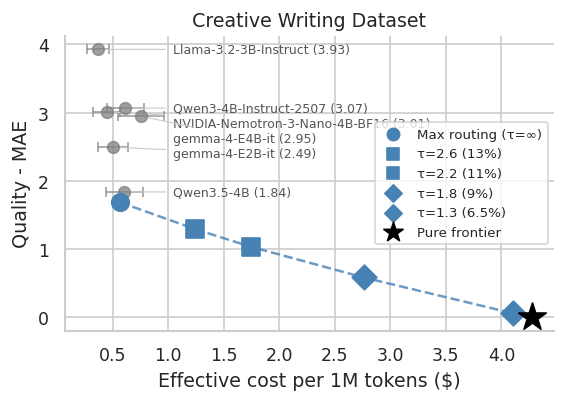

Saved pareto_creative_writing_mae.pdf


In [8]:
# Pareto figure - actual cost ($/1M) on x-axis
FIGURES_DIR = Path("../figures")

# Compute overall MAE per model from errors
model_mae = (
    errors.groupby("evaluator")["abs_err"].mean()
    .reset_index()
    .rename(columns={"evaluator": "model", "abs_err": "Overall MAE"})
)
model_info = cost_df[["model", "cost_mid", "cost_low", "cost_high"]].copy()
model_info = model_info.merge(model_mae, on="model", how="inner")
model_info = model_info.sort_values("Overall MAE", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5, 3.5))

# --- Grey model dots with staggered labels ---
for _, row in model_info.iterrows():
    xerr = (row["cost_high"] - row["cost_low"]) / 2
    ax.errorbar(row["cost_mid"], row["Overall MAE"], xerr=xerr,
                fmt="o", color="grey", alpha=0.75, markersize=7,
                elinewidth=1, capsize=3, zorder=3)

x_label = model_info["cost_high"].max() + 0.08
label_ys = list(model_info["Overall MAE"])
min_gap = 0.22
for i in range(1, len(label_ys)):
    if label_ys[i - 1] - label_ys[i] < min_gap:
        label_ys[i] = label_ys[i - 1] - min_gap

for (_, row), ly in zip(model_info.iterrows(), label_ys):
    ax.annotate(
        f"{row['model']} ({row['Overall MAE']:.2f})",
        xy=(row["cost_mid"], row["Overall MAE"]),
        xytext=(x_label, ly),
        fontsize=7.5, color="#555", ha="left", va="center",
        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.7),
    )

# --- MOJO operating points ---
marker_map = ["o", "s", "s", "D", "D"]
mojo_sorted = mojo_df.sort_values("blended_cost").reset_index(drop=True)
ax.plot(mojo_sorted["blended_cost"], mojo_sorted["realized_mae"],
        "--", color="steelblue", lw=1.5, alpha=0.8, zorder=2)

for i, row in mojo_sorted.iterrows():
    ax.scatter(row["blended_cost"], row["realized_mae"],
               s=110, marker=marker_map[i], color="steelblue", zorder=4,
               label=row["label"])

# --- Pure frontier ---
ax.scatter(CLAUDE_BLENDED, 0, marker="*", s=300, color="black", zorder=5,
           label="Pure frontier")

ax.set_xlabel("Effective cost per 1M tokens ($)")
ax.set_ylabel("Quality - MAE")
ax.set_title("Creative Writing Dataset")
ax.legend(loc="center right", fontsize=8, frameon=True, markerscale=0.7)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_creative_writing_mae.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "pareto_creative_writing_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pareto_creative_writing_mae.pdf")

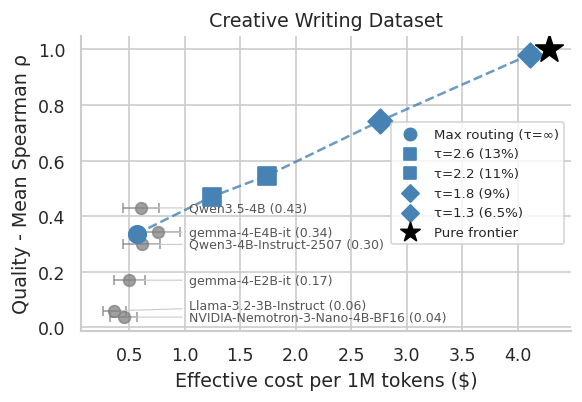

Saved pareto_creative_writing_rho.pdf


In [9]:
# Pareto figure - Spearman ρ on y-axis
model_rho = (
    rho_table.mean(axis=0)
    .reset_index()
    .rename(columns={"evaluator": "model", 0: "Mean Spearman rho"})
)
model_rho.columns = ["model", "Mean Spearman rho"]
model_info_rho = cost_df[["model", "cost_mid", "cost_low", "cost_high"]].copy()
model_info_rho = model_info_rho.merge(model_rho, on="model", how="inner")
model_info_rho = model_info_rho.sort_values("Mean Spearman rho").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5, 3.5))

# --- Grey model dots ---
for _, row in model_info_rho.iterrows():
    xerr = (row["cost_high"] - row["cost_low"]) / 2
    ax.errorbar(row["cost_mid"], row["Mean Spearman rho"], xerr=xerr,
                fmt="o", color="grey", alpha=0.75, markersize=7,
                elinewidth=1, capsize=3, zorder=3)

x_label = model_info_rho["cost_high"].max() + 0.08
label_ys = list(model_info_rho["Mean Spearman rho"])
min_gap = 0.04
for i in range(1, len(label_ys)):
    if label_ys[i] - label_ys[i - 1] < min_gap:
        label_ys[i] = label_ys[i - 1] + min_gap

for (_, row), ly in zip(model_info_rho.iterrows(), label_ys):
    ax.annotate(
        f"{row['model']} ({row['Mean Spearman rho']:.2f})",
        xy=(row["cost_mid"], row["Mean Spearman rho"]),
        xytext=(x_label, ly),
        fontsize=7.5, color="#555", ha="left", va="center",
        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.7),
    )

# --- MOJO operating points ---
marker_map = ["o", "s", "s", "D", "D"]
mojo_sorted = mojo_df.sort_values("blended_cost").reset_index(drop=True)
ax.plot(mojo_sorted["blended_cost"], mojo_sorted["realized_rho"],
        "--", color="steelblue", lw=1.5, alpha=0.8, zorder=2)

for i, row in mojo_sorted.iterrows():
    ax.scatter(row["blended_cost"], row["realized_rho"],
               s=110, marker=marker_map[i], color="steelblue", zorder=4,
               label=row["label"])

# --- Pure frontier ---
ax.scatter(CLAUDE_BLENDED, 1.0, marker="*", s=300, color="black", zorder=5,
           label="Pure frontier")

ax.set_xlabel("Effective cost per 1M tokens ($)")
ax.set_ylabel("Quality - Mean Spearman ρ")
ax.set_title("Creative Writing Dataset")
ax.legend(loc="center right", fontsize=8, frameon=True, markerscale=0.7)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_creative_writing_rho.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "pareto_creative_writing_rho.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pareto_creative_writing_rho.pdf")

## Combined LaTeX Table (individual models + MOJO)

In [10]:
# ── Combined LaTeX table: individual models + MOJO rows ──────────────────────
# CW ρ/τ: pooled across all scores in each polarity group (matches alignment notebook)
# SWB ρ/τ: mean of per-category values (matches SWB MOJO notebook convention)

# ── 1. Load SWB data and compute per-rubric metrics ──────────────────────────
SWB_RESULTS = Path("../../story_writing_benchmark/dataset/results")
SWB_KEYS    = ["index", "prompt_id", "model"]

SWB_CATEGORIES = [
    "Grammar, Spelling, and Punctuation Quality",
    "Clarity and Understandability",
    "Logical Connection Between Events and Ideas",
    "Scene Construction and Purpose",
    "Internal Consistency",
    "Character Consistency",
    "Character Motivation and Actions",
    "Sentence Pattern Variety",
    "Avoidance of Clichés and Overused Phrases",
    "Natural Dialogue",
    "Avoidance of Predictable Narrative Tropes",
    "Character Depth and Dimensionality",
    "Realistic Character Interactions",
    "Ability to Hold Reader Interest",
    "Satisfying Plot Resolution",
]

def _load_swb_pairs():
    def _pretty(s): return s.replace("_result", "")
    raw      = {p.stem: pd.read_csv(p) for p in sorted(SWB_RESULTS.glob("*_result.csv"))}
    baseline = pd.read_csv(SWB_RESULTS / "claude_sonnet_4.6_result.csv")
    raw.pop("claude_sonnet_4.6_result", None)
    evaluators = {_pretty(k): v for k, v in raw.items()}
    ev_names   = sorted(evaluators.keys())
    pair_frames, err_frames = [], []
    for name, df in evaluators.items():
        m = df.merge(baseline, on=SWB_KEYS, suffixes=("_ev", "_ref"), validate="one_to_one")
        for cat in SWB_CATEGORIES:
            col = f"{cat}_score"
            ref = m[f"{col}_ref"].to_numpy()
            sc  = m[f"{col}_ev"].to_numpy()
            pair_frames.append(pd.DataFrame({
                "evaluator": name, "category": cat,
                "baseline": ref, "score": sc,
            }))
            block = m[SWB_KEYS].copy()
            block["category"]  = cat
            block["evaluator"] = name
            block["abs_err"]   = np.abs(ref - sc)
            err_frames.append(block)
    return (pd.concat(pair_frames, ignore_index=True),
            pd.concat(err_frames,  ignore_index=True),
            ev_names)

swb_pairs, swb_errors, swb_ev_names = _load_swb_pairs()

swb_cat_mae = (
    swb_errors.groupby(["evaluator", "category"])["abs_err"].mean()
              .unstack("evaluator")
              .reindex(index=SWB_CATEGORIES, columns=swb_ev_names)
)

swb_corr_rows = []
for (ev, cat), g in swb_pairs.groupby(["evaluator", "category"]):
    x = g["baseline"].to_numpy(); y = g["score"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y)); x, y = x[mask], y[mask]
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rho = float(stats.spearmanr(x, y)[0])
        tau = float(stats.kendalltau(x, y)[0])
    else:
        rho = tau = float("nan")
    swb_corr_rows.append({"evaluator": ev, "category": cat, "rho": rho, "tau": tau})

swb_corr_df   = pd.DataFrame(swb_corr_rows)
swb_rho_table = (
    swb_corr_df.pivot_table(index="category", columns="evaluator", values="rho")
               .reindex(index=SWB_CATEGORIES, columns=swb_ev_names)
)
swb_tau_table = (
    swb_corr_df.pivot_table(index="category", columns="evaluator", values="tau")
               .reindex(index=SWB_CATEGORIES, columns=swb_ev_names)
)

# SWB bootstrap calibration → routing decisions
swb_cal = bootstrap_calibration(swb_pairs, k=5, alpha=0.05, seed=0)
swb_score_table = (
    swb_cal.pivot_table(index="category", columns="evaluator", values="ucb_mae")
           .reindex(index=SWB_CATEGORIES, columns=swb_ev_names)
)

# ── 2. CW pooled ρ/τ per model per polarity ───────────────────────────────────
def _cw_pooled_corr(model, rubric_list):
    """Spearman ρ and Kendall τ by pooling all (evaluator, rubric) score pairs."""
    g = pairs[(pairs["evaluator"] == model) & (pairs["category"].isin(rubric_list))]
    x = g["baseline"].to_numpy(); y = g["score"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y)); x, y = x[mask], y[mask]
    rho = float(stats.spearmanr(x, y)[0]) if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0 else float("nan")
    tau = float(stats.kendalltau(x, y)[0]) if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0 else float("nan")
    return rho, tau

# ── 3. MOJO helpers ───────────────────────────────────────────────────────────
def _mojo_mae(rubrics, ucb_tbl, candidates, mae_tbl, thr):
    maes = []
    for rubric in rubrics:
        eligible = sorted([(ucb_tbl.loc[rubric, m], m) for m in candidates
                           if ucb_tbl.loc[rubric, m] <= thr])
        maes.append(0.0 if not eligible else float(mae_tbl.loc[rubric, eligible[0][1]]))
    return float(np.mean(maes))

def _mojo_cw_pooled_corr(rubric_list, ucb_tbl, candidates, pairs_df, thr):
    """Pooled Spearman ρ / Kendall τ for a MOJO-routed CW polarity group."""
    all_x, all_y = [], []
    for rubric in rubric_list:
        eligible = sorted([(ucb_tbl.loc[rubric, m], m) for m in candidates
                           if ucb_tbl.loc[rubric, m] <= thr])
        if not eligible:
            # Escalated to Claude: score equals baseline (perfect)
            g = pairs_df[pairs_df["category"] == rubric].groupby("evaluator").first().reset_index()
            ref_vals = pairs_df[(pairs_df["category"] == rubric) &
                                (pairs_df["evaluator"] == candidates[0])]["baseline"].dropna().to_numpy()
            all_x.extend(ref_vals); all_y.extend(ref_vals)
        else:
            _, m = eligible[0]
            g = pairs_df[(pairs_df["category"] == rubric) & (pairs_df["evaluator"] == m)]
            x = g["baseline"].to_numpy(); y = g["score"].to_numpy()
            mask = ~(np.isnan(x) | np.isnan(y))
            all_x.extend(x[mask]); all_y.extend(y[mask])
    x = np.array(all_x); y = np.array(all_y)
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        return float(stats.spearmanr(x, y)[0]), float(stats.kendalltau(x, y)[0])
    return 1.0, 1.0

def _mojo_swb_corr(rubrics, ucb_tbl, candidates, mae_tbl, rho_tbl, tau_tbl, thr):
    maes, rhos, taus = [], [], []
    for rubric in rubrics:
        eligible = sorted([(ucb_tbl.loc[rubric, m], m) for m in candidates
                           if ucb_tbl.loc[rubric, m] <= thr])
        if not eligible:
            mae_v, rho_v, tau_v = 0.0, 1.0, 1.0
        else:
            _, m = eligible[0]
            mae_v = float(mae_tbl.loc[rubric, m])
            rho_v = float(rho_tbl.loc[rubric, m])
            tau_v = float(tau_tbl.loc[rubric, m])
        maes.append(mae_v); rhos.append(rho_v); taus.append(tau_v)
    return float(np.mean(maes)), float(np.mean(rhos)), float(np.mean(taus))

# ── 4. Build table rows ───────────────────────────────────────────────────────
MODEL_ORDER = [
    "Qwen3.5-4B", "gemma-4-E2B-it", "gemma-4-E4B-it",
    "NVIDIA-Nemotron-3-Nano-4B-BF16", "Qwen3-4B-Instruct-2507",
    "Llama-3.2-3B-Instruct",
]

table_rows = []

for model in MODEL_ORDER:
    pos_rho, pos_tau = _cw_pooled_corr(model, POSITIVE_CATEGORIES)
    neg_rho, neg_tau = _cw_pooled_corr(model, NEGATIVE_CATEGORIES)
    table_rows.append({
        "name":       model,
        "is_mojo":    False,
        "cw_pos_mae": float(cat_mae.loc[POSITIVE_CATEGORIES, model].mean()),
        "cw_pos_rho": pos_rho, "cw_pos_tau": pos_tau,
        "cw_neg_mae": float(cat_mae.loc[NEGATIVE_CATEGORIES, model].mean()),
        "cw_neg_rho": neg_rho, "cw_neg_tau": neg_tau,
        "swb_mae":    float(swb_cat_mae[model].mean()),
        "swb_rho":    float(swb_rho_table[model].mean()),
        "swb_tau":    float(swb_tau_table[model].mean()),
    })

# MOJO rows — thresholds paired by % of score range (CW 0–20, SWB 0–5)
PAIRED = [
    ("Max (Tol=$\\infty$)", float("inf"), float("inf")),
    ("Tol=13\\%",           2.6,          0.65),
    ("Tol=11\\%",           2.2,          0.55),
    ("Tol=9\\%",            1.8,          0.45),
    ("Tol=6.5\\%",          1.3,          0.33),
]

for label, cw_thr, swb_thr in PAIRED:
    pm  = _mojo_mae(POSITIVE_CATEGORIES, score_table, CANDIDATE_MODELS, cat_mae, cw_thr)
    nm  = _mojo_mae(NEGATIVE_CATEGORIES, score_table, CANDIDATE_MODELS, cat_mae, cw_thr)
    pr, pt = _mojo_cw_pooled_corr(POSITIVE_CATEGORIES, score_table, CANDIDATE_MODELS, pairs, cw_thr)
    nr, nt = _mojo_cw_pooled_corr(NEGATIVE_CATEGORIES, score_table, CANDIDATE_MODELS, pairs, cw_thr)
    sm, sr, st = _mojo_swb_corr(SWB_CATEGORIES, swb_score_table, swb_ev_names,
                                 swb_cat_mae, swb_rho_table, swb_tau_table, swb_thr)
    table_rows.append({
        "name":       f"MOJO ({label})",
        "is_mojo":    True,
        "cw_pos_mae": pm, "cw_pos_rho": pr, "cw_pos_tau": pt,
        "cw_neg_mae": nm, "cw_neg_rho": nr, "cw_neg_tau": nt,
        "swb_mae":    sm, "swb_rho":    sr, "swb_tau":    st,
    })

# ── 5. Best-per-metric among individual models (for bolding) ─────────────────
model_only = [r for r in table_rows if not r["is_mojo"]]
METRICS    = ["cw_pos_mae", "cw_pos_rho", "cw_pos_tau",
              "cw_neg_mae", "cw_neg_rho", "cw_neg_tau",
              "swb_mae",    "swb_rho",    "swb_tau"]
HIGHER     = {"cw_pos_rho", "cw_pos_tau", "cw_neg_rho", "cw_neg_tau", "swb_rho", "swb_tau"}

best = {
    m: max(r[m] for r in model_only) if m in HIGHER else min(r[m] for r in model_only)
    for m in METRICS
}

def _cell(val, metric):
    if val is None: return "---"
    s = f"$-${abs(val):.3f}" if val < 0 else f"{val:.3f}"
    return r"\textbf{" + s + r"}" if abs(val - best[metric]) < 1e-9 else s

def _mojo_cell(val):
    if val is None: return "---"
    return f"$-${abs(val):.3f}" if val < 0 else f"{val:.3f}"

# ── 6. Render LaTeX ───────────────────────────────────────────────────────────
lines = [
    r"\caption{Alignment against the Claude Sonnet 4.6 baseline across both datasets."
    r" MAE~$\downarrow$, Spearman~$\rho$~$\uparrow$, Kendall~$\tau$~$\uparrow$.}",
    r"\label{table:results}",
    r"\small",
    r"\resizebox{\textwidth}{!}{%",
    r"\begin{tabular}{lcccccc|ccc}",
    r"\toprule",
    r"& \multicolumn{6}{c|}{\textbf{Creative Writing}} & \multicolumn{3}{c}{\textbf{SWB}} \\",
    r"\cmidrule(lr){2-7} \cmidrule(lr){8-10}",
    r"& \multicolumn{3}{c}{\textbf{Positive}} & \multicolumn{3}{c|}{\textbf{Negative}} & & & \\",
    (r"\textbf{Evaluator} & \textbf{MAE} & \textbf{$\rho$} & \textbf{$\tau$}"
     r" & \textbf{MAE} & \textbf{$\rho$} & \textbf{$\tau$}"
     r" & \textbf{MAE} & \textbf{$\rho$} & \textbf{$\tau$} \\"),
    r"\midrule",
]

for r in model_only:
    n = r["name"]
    lines.append(
        f"{n:<35} & {_cell(r['cw_pos_mae'],'cw_pos_mae')} & {_cell(r['cw_pos_rho'],'cw_pos_rho')}"
        f" & {_cell(r['cw_pos_tau'],'cw_pos_tau')} & {_cell(r['cw_neg_mae'],'cw_neg_mae')}"
        f" & {_cell(r['cw_neg_rho'],'cw_neg_rho')} & {_cell(r['cw_neg_tau'],'cw_neg_tau')}"
        f" & {_cell(r['swb_mae'],'swb_mae')} & {_cell(r['swb_rho'],'swb_rho')}"
        f" & {_cell(r['swb_tau'],'swb_tau')} \\\\"
    )

lines += [
    r"\midrule",
    r"Claude Sonnet 4.6 (Ref)            & --- & --- & --- & --- & --- & --- & --- & --- & --- \\",
    r"\midrule",
]

for r in [r for r in table_rows if r["is_mojo"]]:
    n = r["name"]
    lines.append(
        f"{n:<35} & {_mojo_cell(r['cw_pos_mae'])} & {_mojo_cell(r['cw_pos_rho'])}"
        f" & {_mojo_cell(r['cw_pos_tau'])} & {_mojo_cell(r['cw_neg_mae'])}"
        f" & {_mojo_cell(r['cw_neg_rho'])} & {_mojo_cell(r['cw_neg_tau'])}"
        f" & {_mojo_cell(r['swb_mae'])} & {_mojo_cell(r['swb_rho'])}"
        f" & {_mojo_cell(r['swb_tau'])} \\\\"
    )

lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"}%  % end resizebox",
]

print("\n".join(lines))

\caption{Alignment against the Claude Sonnet 4.6 baseline across both datasets. MAE~$\downarrow$, Spearman~$\rho$~$\uparrow$, Kendall~$\tau$~$\uparrow$.}
\label{table:results}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc|ccc}
\toprule
& \multicolumn{6}{c|}{\textbf{Creative Writing}} & \multicolumn{3}{c}{\textbf{SWB}} \\
\cmidrule(lr){2-7} \cmidrule(lr){8-10}
& \multicolumn{3}{c}{\textbf{Positive}} & \multicolumn{3}{c|}{\textbf{Negative}} & & & \\
\textbf{Evaluator} & \textbf{MAE} & \textbf{$\rho$} & \textbf{$\tau$} & \textbf{MAE} & \textbf{$\rho$} & \textbf{$\tau$} & \textbf{MAE} & \textbf{$\rho$} & \textbf{$\tau$} \\
\midrule
Qwen3.5-4B                          & \textbf{1.744} & \textbf{0.513} & \textbf{0.383} & \textbf{1.970} & 0.453 & 0.336 & \textbf{0.597} & 0.451 & 0.424 \\
gemma-4-E2B-it                      & 2.044 & 0.309 & 0.231 & 3.139 & 0.206 & 0.152 & 0.669 & 0.409 & 0.395 \\
gemma-4-E4B-it                      & 2.993 & 0.301 & 0.228 & 2.880 & \textbf{0.488}